# PR7 · Drawdown Control: Stop-Losses and Risk Budgets

Investors judge a strategy by its worst stretch. This notebook compares two ways to limit drawdowns: the simple stop-loss, and a rule that scales risk down smoothly as losses build up.

## 1. Motivation

A fund mandate says: "the portfolio must never fall more than 20% from its peak." Breaking that limit means the fund is shut down, whatever happens afterwards. How do you run money under a rule like that? The obvious answer, "sell everything if we lose 15%", turns out to have hidden costs. A smarter rule exists, and it is simple enough to code in a few lines.

## 2. Intuition

**Stop-loss.** When losses reach a threshold, sell everything and wait. It caps the damage, but it raises two problems. When do you get back in? And if the market bounces right after you sell (it often does), you lock in the loss and miss the recovery. This back-and-forth is called **whipsaw**.

**Drawdown control.** Instead of an on/off switch, think of a **risk budget**. If the limit is a 20% drawdown, then at the peak you have 20% of "room" to lose. After a 10% loss you only have 10% left, so you should be taking about half as much risk. At a 20% loss, you have no room left and hold no risk at all. Exposure shrinks smoothly as you approach the limit, and grows back as you recover. You never get forced out all at once.

## 3. The math

Let $V_t$ be portfolio value, $M_t = \max_{s\le t} V_s$ its running peak, and $DD_t = V_t/M_t - 1$ the drawdown (notebook 2).

**Stop-loss rule** with threshold $L$ (e.g. 10%): hold the asset while $DD_t > -L$. Once $DD_t \le -L$, switch to T-bills, and re-enter after a fixed waiting period. The peak $M_t$ is then reset to the current value.

**Drawdown control** (Grossman and Zhou, 1993) with maximum drawdown $d$ (e.g. 20%). The **floor** is the lowest value we are allowed to reach, $F_t = (1-d)\,M_t$. The **cushion** is the distance above it, $V_t - F_t$. Hold a risky exposure proportional to the cushion:
$$
w_t = \min\!\left( m\,\frac{V_t - F_t}{V_t},\; 1 \right),
$$
where $m$ is a **multiplier** controlling aggressiveness, and the cap of 1 means no leverage. At the peak, $(V_t - F_t)/V_t = d$, so the exposure is $m \times d$ (e.g. $3 \times 20\% = 60\%$, or 100% if capped). As $V_t \to F_t$, the exposure goes to zero.

If you could rebalance continuously, $V_t$ would never fall below $F_t$, so the drawdown would never exceed $d$. With daily rebalancing, a single large overnight gap can still break the floor. The larger $m$, the bigger the gap needed: the floor breaks if one day's loss exceeds $1/m$.

**Calmar ratio.** A common way to rate a strategy against its drawdown: $\text{Calmar} = \text{CAGR}/|\text{Max drawdown}|$.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

spy = prices["SPY"].pct_change().dropna()
rf = ((prices["^IRX"].ffill() / 100 / 252).shift(1)).reindex(spy.index).fillna(0)

### 4.2 Both rules as loops

These rules depend on the strategy's *own* past value, so we step through time one day at a time. Each day, the weight is set from information available at yesterday's close.

In [2]:
def stop_loss(r, rf, L=0.10, wait=21):
    """Hold the asset until drawdown hits -L, then T-bills for `wait` days, then re-enter."""
    value, peak, days_out, out = 1.0, 1.0, 0, []
    for r_t, rf_t in zip(r.values, rf.values):
        w = 0.0 if days_out > 0 else 1.0          # weight chosen at yesterday's close
        value *= 1 + w * r_t + (1 - w) * rf_t
        if days_out > 0:
            days_out -= 1
            if days_out == 0:
                peak = value                       # re-enter: reset the peak
        peak = max(peak, value)
        if days_out == 0 and value / peak - 1 <= -L:
            days_out = wait                        # stop out
        out.append(value)
    return pd.Series(out, index=r.index)

def drawdown_control(r, rf, d=0.20, m=3.0):
    """Exposure = min(m * (V - F) / V, 1), with floor F = (1 - d) * peak."""
    value, peak, out, w_hist = 1.0, 1.0, [], []
    for r_t, rf_t in zip(r.values, rf.values):
        floor = (1 - d) * peak
        w = min(m * (value - floor) / value, 1.0)  # cushion-based exposure, no leverage
        w = max(w, 0.0)
        value *= 1 + w * r_t + (1 - w) * rf_t
        peak = max(peak, value)
        out.append(value)
        w_hist.append(w)
    return pd.Series(out, index=r.index), pd.Series(w_hist, index=r.index)

### 4.3 Compare the rules

In [3]:
dc_value, dc_weight = drawdown_control(spy, rf, d=0.20, m=3.0)
values = pd.DataFrame({
    "Buy & hold": (1 + spy).cumprod(),
    "Stop-loss 10%": stop_loss(spy, rf, L=0.10),
    "DD control 20%": dc_value,
})

def summary(v):
    r = v.pct_change().dropna()
    dd = v / v.cummax() - 1
    cagr = v.iloc[-1] ** (252 / len(v)) - 1
    underwater = (dd < 0).groupby((dd == 0).cumsum()).sum().max()   # longest run below a peak
    return pd.Series({"CAGR": f"{cagr:.1%}", "Volatility": f"{r.std() * np.sqrt(252):.1%}",
                      "Max drawdown": f"{dd.min():.1%}", "Calmar": f"{cagr / -dd.min():.2f}",
                      "Longest underwater": f"{underwater} days"})

values.apply(summary).T

,CAGR,Volatility,Max drawdown,Calmar,Longest underwater
Buy & hold,14.1%,17.1%,-33.7%,0.42,488 days
Stop-loss 10%,14.3%,14.2%,-24.1%,0.59,488 days
DD control 20%,7.3%,7.9%,-15.2%,0.48,480 days


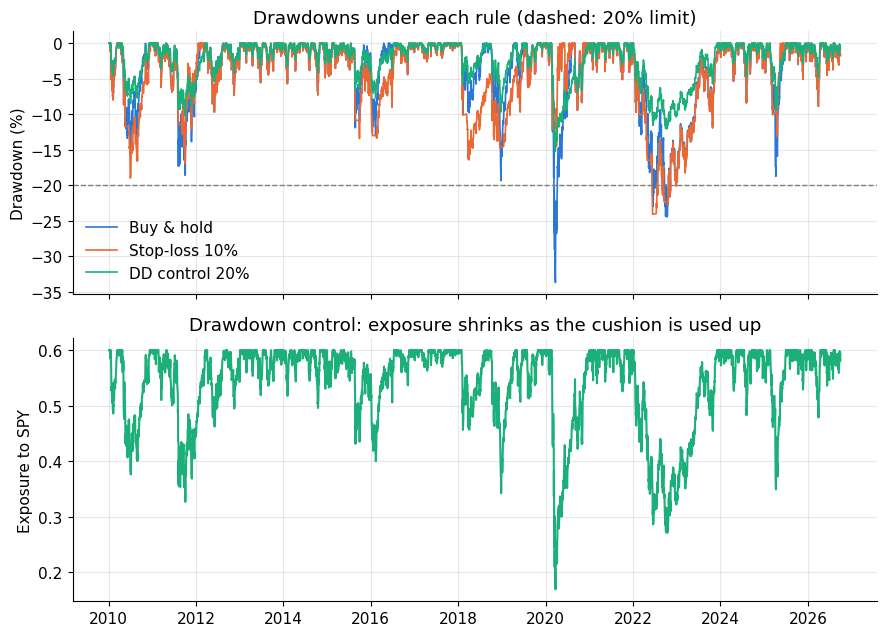

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
for col in values:
    dd = values[col] / values[col].cummax() - 1
    axes[0].plot(dd.index, dd * 100, label=col, linewidth=1.2)
axes[0].axhline(-20, color="grey", ls="--", linewidth=1)
axes[0].set_ylabel("Drawdown (%)")
axes[0].set_title("Drawdowns under each rule (dashed: 20% limit)")
axes[0].legend(frameon=False, loc="lower left")
axes[1].plot(dc_weight.index, dc_weight, color=COLORS[2])
axes[1].set_ylabel("Exposure to SPY")
axes[1].set_title("Drawdown control: exposure shrinks as the cushion is used up")
plt.tight_layout()
plt.show()

- **Drawdown control did what it promised.** Its max drawdown was 15%, inside the 20% limit, even through the 2020 crash. The bottom panel shows how: exposure was cut steadily as losses mounted, to under 20% at the worst point. The price was steep: CAGR halved, because with $m = 3$ the rule holds at most 60% in SPY even at a peak, and it rebuilds exposure slowly after losses.
- **The 10% stop-loss happened to work well here.** It beat buy-and-hold slightly, with a smaller drawdown. Its max drawdown (−24%) is still far beyond the 10% threshold. Each re-entry resets the peak, so several stop-outs in a row add up. A stop-loss limits each episode, not the total.
- **Neither rule shortened the longest time underwater** (about two years, mostly 2022–2023). Avoiding a deep loss is not the same as recovering quickly.

Before concluding that stop-losses are great, look at how sensitive that result is.

### 4.4 How sensitive is the stop-loss to its settings?

In [5]:
grid = []
for L in [0.05, 0.10, 0.15, 0.20]:
    for wait in [5, 21, 63]:
        v = stop_loss(spy, rf, L=L, wait=wait)
        dd = (v / v.cummax() - 1).min()
        cagr = v.iloc[-1] ** (252 / len(v)) - 1
        grid.append({"threshold": L, "wait (days)": wait, "CAGR": cagr, "Max DD": dd})
grid = pd.DataFrame(grid)
print("CAGR by stop-loss threshold (rows) and waiting period (columns):")
print(grid.pivot(index="threshold", columns="wait (days)", values="CAGR").map("{:.1%}".format))
print()
print("Max drawdown:")
print(grid.pivot(index="threshold", columns="wait (days)", values="Max DD").map("{:.1%}".format))

CAGR by stop-loss threshold (rows) and waiting period (columns):
wait (days)     5      21     63
threshold                       
0.05         11.1%   9.3%   3.2%
0.10         13.8%  14.3%  10.9%
0.15         13.5%  11.5%   8.8%
0.20         14.3%  13.3%  12.4%

Max drawdown:
wait (days)      5       21      63
threshold                          
0.05         -24.8%  -19.2%  -20.3%
0.10         -32.7%  -24.1%  -22.8%
0.15         -27.7%  -27.4%  -25.7%
0.20         -31.6%  -27.4%  -27.9%


Across 12 reasonable-looking settings, CAGR ranges from about 3% to 14% and max drawdown from −19% to −33%. The tightest stop (5%) with a long wait was a disaster: it kept selling small dips and then sat in cash during the recoveries. The 10% / 21-day combination from Section 4.3 is one of the luckiest cells in the table. Had we picked it *because* it looked best here, that would be exactly the overfitting from notebook 6. There is no setting that is reliably good, which is the main practical argument against simple stop-losses.

## 5. Takeaways and where it breaks

- **Drawdown limits cost return.** Every rule that cuts exposure after losses also misses part of the rebound. There is no free protection.
- **Smooth beats on/off.** Drawdown control respects its limit by design and never needs a re-entry rule. A stop-loss depends heavily on two arbitrary settings.
- **Path dependence.** Both rules depend on the strategy's own history, so two investors starting on different dates get different results. Always test several start dates.
- **Where it breaks:** the floor guarantee assumes you can trade at yesterday's prices. Overnight gaps, trading halts and illiquid markets can break it. And after a deep drawdown, drawdown control holds almost no risk, so recovery can take a very long time (it can get "stuck" near the floor).
- **Use the right tool for the goal:** volatility targeting (PR5) controls risk going *forward*; drawdown rules react to losses that have already happened.

**What you could build:** a "risk overlay" that sits on top of any team strategy and enforces the club's maximum-drawdown rule, with a report of what the overlay cost in return.